In [1]:
import kagglehub
from torch.optim.lr_scheduler import StepLR

path = kagglehub.dataset_download("grassknoted/asl-alphabet")

print("Path to dataset files:", path)

F:\DeepLearning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\me03h\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1


C:\Users\me03h\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.image as mpimg
import os

import torch
import torchvision
import torchvision.transforms as transforms

['asl_alphabet_test', 'asl_alphabet_train']
C:\Users\me03h\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train\asl_alphabet_train\A\A1.jpg


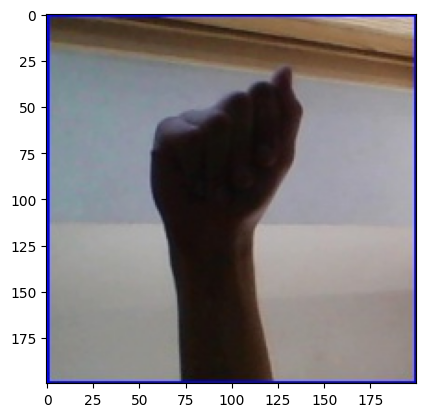

In [3]:
path = "C:\\Users\\me03h\\.cache\\kagglehub\\datasets\\grassknoted\\asl-alphabet\\versions\\1"
classes = os.listdir(path)
print(classes)


train_path = os.path.join(path, 'asl_alphabet_train', 'asl_alphabet_train')
test_path = os.path.join(path, 'asl_alphabet_test', 'asl_alphabet_test')

img_path = os.path.join(train_path, 'A', 'A1.jpg')
print(img_path)

img = mpimg.imread(img_path)
plt.imshow(img)
plt.show()

In [4]:
from PIL import Image, ImageFilter
# .point(lambda p: p > 80 and 255)
class EdgeDetect:
    def __call__(self, img):
        img = img.convert('L')
        img = img.filter(ImageFilter.FIND_EDGES).point(lambda p: p > 35 and 255)
        return img

In [5]:
from torch.utils.data import random_split

transform = transforms.Compose([
    # transforms.Resize((128, 128)),
    EdgeDetect(), # convert images to gray scale and then detect edges
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
    ])

classes = ('A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space')


trainset = torchvision.datasets.ImageFolder(root=train_path, transform=transform)
batch_size = 8
# trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
#                                           shuffle=True, num_workers=2)
#
# testset = torchvision.datasets.ImageFolder(root=test_path, transform=transform)
# testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
#                                           shuffle=True, num_workers=2)

test_ratio = 0.1 # take 10% of train set
test_size = int(test_ratio * len(trainset))
train_size = len(trainset) - test_size

trainset, testset = random_split(trainset, [train_size, test_size])

trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=0)

testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=0)

print(len(trainset))
print(len(testset))


78300
8700


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [7]:
import time
start = time.time()
dataiter = iter(trainloader)
images, labels = next(dataiter)
end = time.time()
print(f"Time to load 1 batch: {end - start:.2f} seconds")


Time to load 1 batch: 0.02 seconds


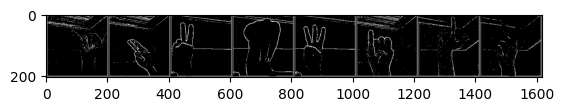

Y     H     V     M     W     I     L     K    


In [8]:
def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

In [9]:
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(in_features=128 * 25 * 25, out_features=512)
        self.fc2 = nn.Linear(in_features=512, out_features=128)
        self.fc3 = nn.Linear(in_features=128, out_features=29)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x) # no relu as using softmax in the end
        return x

CNN = CNN()
CNN.to(device)
print(CNN)

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=80000, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=29, bias=True)
)


In [10]:
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(CNN.parameters(), lr=0.001, momentum=0.9)
scheduler = StepLR(optimizer, step_size=2, gamma=0.2)

train_losses = []
test_losses = []

for epoch in range(2):
    running_loss = 0.0
    CNN.train()
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = CNN(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 100 == 99:
            print(f'Epoch: {epoch + 1}, [{i + 1}, {len(trainloader)}] loss: {loss.item():.3f}  '
                  f'Running loss: {running_loss / 100:.3f}')
            running_loss = 0.0

    scheduler.step()

    CNN.eval()
    total_train_loss = 0
    with torch.no_grad():
        for i, data in enumerate(trainloader, 0):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = CNN(inputs)
            loss = criterion(outputs, labels)
            total_train_loss += loss.item()
    avg_train_loss = total_train_loss / len(trainloader)
    train_losses.append(avg_train_loss)

    total_test_loss = 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = CNN(inputs)
            loss = criterion(outputs, labels)
            total_test_loss += loss.item()
    avg_test_loss = total_test_loss / len(testloader)
    test_losses.append(avg_test_loss)

    print(f'Epoch {epoch+1} complete. Train Loss: {avg_train_loss:.3f}, Test Loss: {avg_test_loss:.3f}')



Epoch: 1, [100, 9788] loss: 3.374  Running loss: 3.369
Epoch: 1, [200, 9788] loss: 3.392  Running loss: 3.368
Epoch: 1, [300, 9788] loss: 3.362  Running loss: 3.369
Epoch: 1, [400, 9788] loss: 3.369  Running loss: 3.366
Epoch: 1, [500, 9788] loss: 3.369  Running loss: 3.365
Epoch: 1, [600, 9788] loss: 3.361  Running loss: 3.366
Epoch: 1, [700, 9788] loss: 3.342  Running loss: 3.365
Epoch: 1, [800, 9788] loss: 3.355  Running loss: 3.364
Epoch: 1, [900, 9788] loss: 3.349  Running loss: 3.357
Epoch: 1, [1000, 9788] loss: 3.331  Running loss: 3.354
Epoch: 1, [1100, 9788] loss: 3.330  Running loss: 3.341
Epoch: 1, [1200, 9788] loss: 3.353  Running loss: 3.328
Epoch: 1, [1300, 9788] loss: 3.163  Running loss: 3.305
Epoch: 1, [1400, 9788] loss: 3.307  Running loss: 3.257
Epoch: 1, [1500, 9788] loss: 2.747  Running loss: 3.160
Epoch: 1, [1600, 9788] loss: 2.964  Running loss: 3.018
Epoch: 1, [1700, 9788] loss: 2.716  Running loss: 2.845
Epoch: 1, [1800, 9788] loss: 3.300  Running loss: 2.726
E

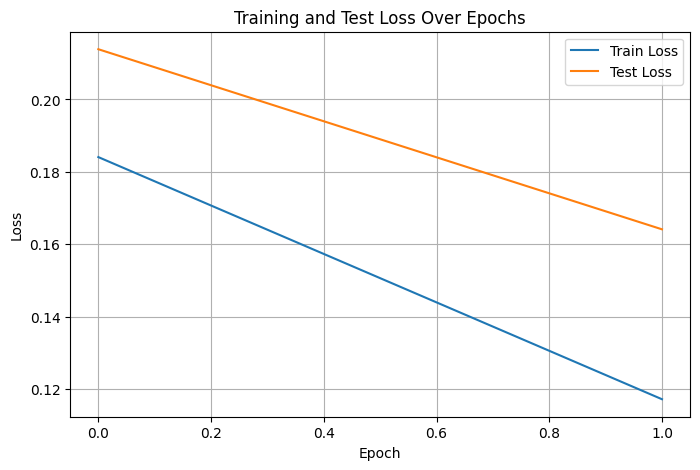

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()


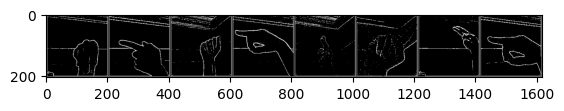

GroundTruth:  M     G     A     P     R     Z     H     P    


In [12]:
dataiter = iter(testloader)
images, labels = next(dataiter)
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

In [13]:
images, labels = images.to(device), labels.to(device)
outputs = CNN(images)

_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}'
                              for j in range(batch_size)))

Predicted:  M     G     A     P     R     Z     H     P    


In [14]:
correct = 0
total = 0

all_preds = []
all_labels = []
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        outputs = CNN(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the {total} test images: {100 * correct // total} %')

Accuracy of the network on the 8700 test images: 94 %


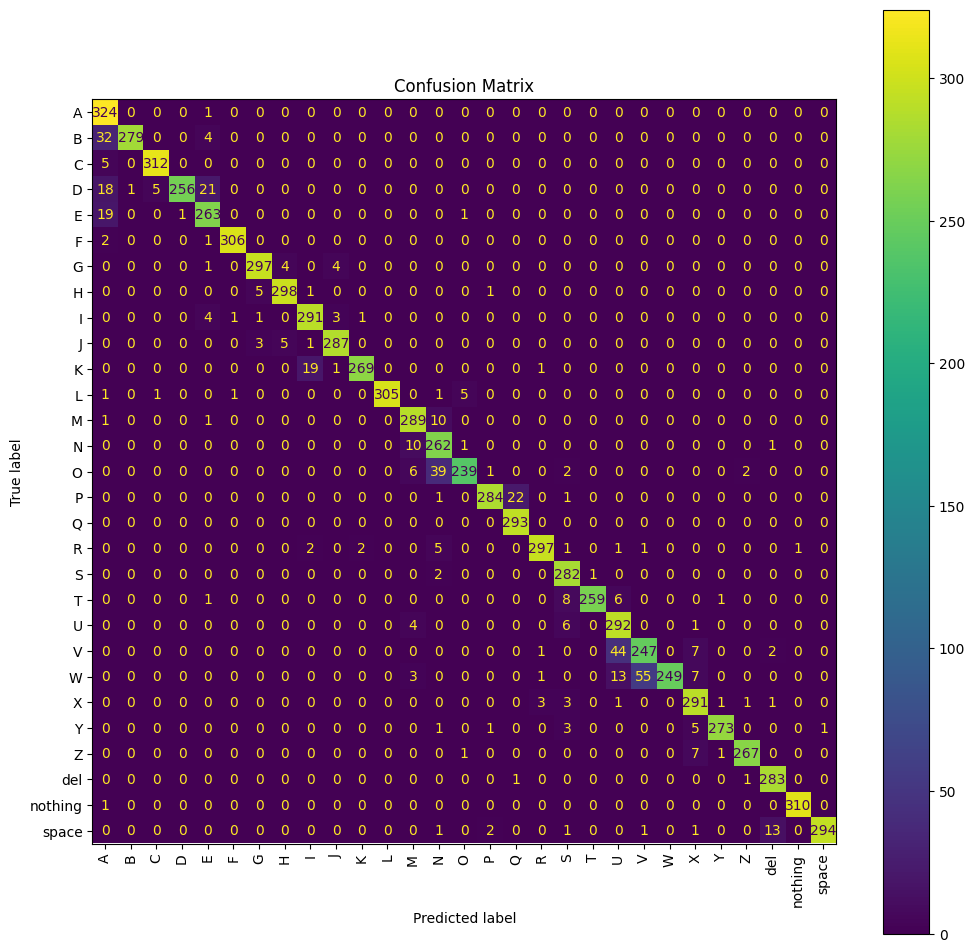

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax, xticks_rotation=90)
plt.title("Confusion Matrix")
plt.show()

In [16]:
torch.save(CNN.state_dict(), 'CNN_Model_6.pth')